In [77]:
import pandas as pd
import numpy as np

In [78]:
df= pd.read_csv("./datasets/null.csv")

In [79]:
df.head()

,ID,Name,Age,Salary,Department
0,1,John,28.0,50000.0,IT
1,2,Mary,32.0,NaN,HR
2,3,Bob,45.0,70000.0,Finance
3,4,Alice,29.0,55000.0,IT
4,5,Tom,35.0,60000.0,HR


In [80]:
df.isnull().head()    #gives a dataset having True when the value is null else false

,ID,Name,Age,Salary,Department
0,False,False,False,False,False
1,False,False,False,True,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False


In [81]:
df.isnull().mean()*100

ID             0.0
Name           0.0
Age           10.0
Salary         5.0
Department     0.0
dtype: float64

# 1 Remove the rows or column containing the null variable
    - Only remove the rows if the null value data is completely at random
    - After removing the data, it shouldnt disturb the distribution of dataset(can be checked through histplot)
    - Only remove the null value is less than or equal to 5% of total data

In [82]:
column= [x for x in df.columns if df[x].isnull().mean()*100 <= 5 and df[x].isnull().mean()*100>0]
column

['Salary']

In [83]:
new_df= df.dropna(subset= ['Salary'])

In [84]:
df.shape

(20, 5)

In [85]:
new_df.shape

(19, 5)

In [86]:
df.isnull().sum()

ID            0
Name          0
Age           2
Salary        1
Department    0
dtype: int64

In [87]:
new_df.isnull().sum()

ID            0
Name          0
Age           2
Salary        0
Department    0
dtype: int64

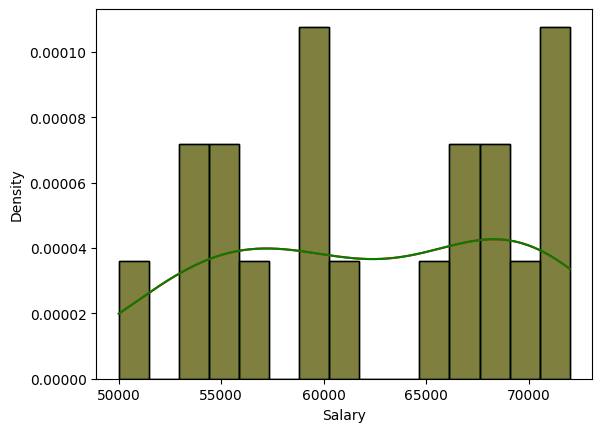

In [88]:
# to check the disribution
import seaborn as sns
import matplotlib.pyplot as plt



sns.histplot(df['Salary'], color= 'red', stat= 'density', bins= 15, kde= True)
sns.histplot(new_df['Salary'], color= 'green', stat='density', bins= 15, kde= True)    #if both are same then we can say their distribution didnt change

plt.show()

In [89]:
len(new_df)/len(df) * 100    #len gives no of rows in dataframe

95.0

<Axes: >

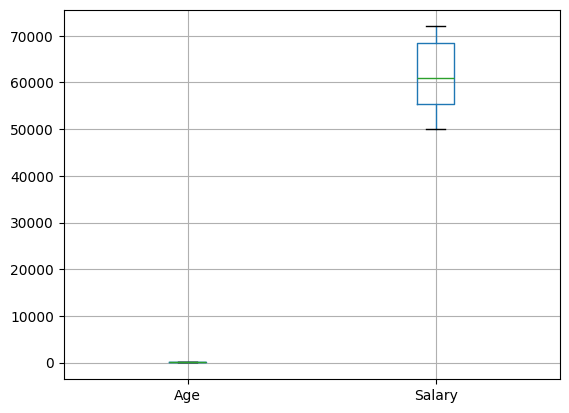

In [90]:
df[['Age', 'Salary']].boxplot()

<Axes: >

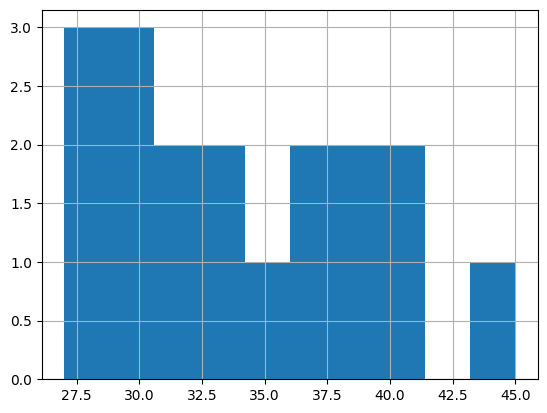

In [91]:
df['Age'].hist()

## Random Value(can be done only using pandas)
    - can be used both for categorical and numerical

In [92]:
df= pd.read_csv('./datasets/train.csv', usecols= ['Age', 'Survived', 'Fare'])

In [93]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [94]:
df['Age'].sample(5)

267    25.0
552     NaN
769    32.0
806    39.0
865    42.0
Name: Age, dtype: float64

In [95]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [96]:
df['Age_without_null']= df['Age']

In [97]:
df.head()

,Survived,Age,Fare,Age_without_null
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


In [98]:
## REplacing NA by random values where in age_without_null
df.loc[df['Age_without_null'].isnull(), 'Age_without_null']= df.dropna(subset= 'Age_without_null')['Age_without_null'].sample(df['Age_without_null'].isnull().sum()).values

In [99]:
df.isnull().sum()

Survived              0
Age                 177
Fare                  0
Age_without_null      0
dtype: int64

In [100]:
df['Age']> 5

0       True
1       True
2       True
3       True
4       True
       ...  
886     True
887     True
888    False
889     True
890     True
Name: Age, Length: 891, dtype: bool

In [101]:
df

,Survived,Age,Fare,Age_without_null
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0
...,...,...,...,...
886,0,27.0,13.0000,27.0
887,1,19.0,30.0000,19.0
888,0,NaN,23.4500,51.0
889,1,26.0,30.0000,26.0


C:\Users\Yunish\AppData\Local\Temp\ipykernel_2556\4205809213.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


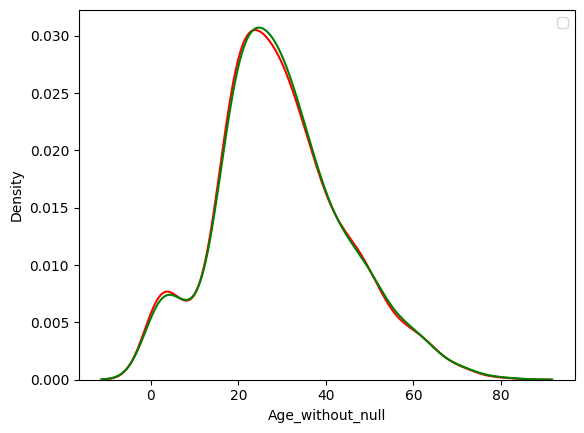

In [102]:
import seaborn as sns
import matplotlib.pyplot as  plt

#plt.figure(figsize= (14, 4))

sns.kdeplot(df['Age_without_null'], color= 'red')

sns.kdeplot(df['Age'], color= 'green')
plt.legend()

plt.show()



In [103]:
df.cov()

,Survived,Age,Fare,Age_without_null
Survived,0.236772,-0.551296,6.221787,-0.549507
Age,-0.551296,211.019125,73.849030,211.019125
Fare,6.221787,73.849030,2469.436846,54.629322
Age_without_null,-0.549507,211.019125,54.629322,212.685360


## for categorical data

In [104]:
df= pd.read_csv("./datasets/train.csv")




In [105]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [106]:
df= df.iloc[:, [10, 1, 4]]

In [107]:
df.head()

,Cabin,Survived,Sex
0,NaN,0,male
1,C85,1,female
2,NaN,1,female
3,C123,1,female
4,NaN,0,male


In [108]:
df['Cabin_without_null']= df['Cabin']

In [109]:
df.loc[df["Cabin_without_null"].isnull(), 'Cabin_without_null']= df.dropna(subset= ['Cabin_without_null'])['Cabin_without_null'].sample(df['Cabin_without_null'].isnull().sum(), replace= True).values

In [110]:
df['Cabin_without_null'].isnull().sum()

np.int64(0)

In [111]:
df.sample(5)

,Cabin,Survived,Sex,Cabin_without_null
769,NaN,0,male,C47
645,D33,1,male,D33
151,C2,1,female,C2
602,NaN,0,male,C125
90,NaN,0,male,C123


In [112]:
df.isnull().sum()

Cabin                 687
Survived                0
Sex                     0
Cabin_without_null      0
dtype: int64

## Missing Indicator

In [113]:
from sklearn.impute import MissingIndicator

mi= MissingIndicator()   # makes new column for each column which has null values and and in that column there will be False if there is no null value prior to its original column and places True if there is null value in that new column

df= pd.read_csv("./datasets/train.csv", usecols= ['Age', 'Cabin', 'Survived'])

In [114]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(df.drop(columns= ['Survived']), df['Survived'], train_size= 0.8)

In [115]:
x_train

,Age,Cabin
506,33.0,NaN
869,4.0,NaN
883,28.0,NaN
441,20.0,NaN
802,11.0,B96 B98
...,...,...
849,NaN,C92
430,28.0,C52
40,40.0,NaN
25,38.0,NaN


In [116]:
x_train_imputed= mi.fit_transform(x_train)
x_test_imputed= mi.transform(x_test)

In [117]:
mi.get_feature_names_out()

array(['missingindicator_Age', 'missingindicator_Cabin'], dtype=object)

In [118]:
pd.DataFrame(x_train_imputed, columns= mi.get_feature_names_out())

,missingindicator_Age,missingindicator_Cabin
0,False,True
1,False,True
2,False,True
3,False,True
4,False,False
...,...,...
707,True,False
708,False,False
709,False,True
710,False,True


We also can use add_indicator inside the Simple Imputer so that it automatically add indicator like this and fill the null at the same time. So this Simple Imputer method is preffered than the one I did in above

## Multivariate Imputation

### KNN imputation

In [119]:
from sklearn.impute import KNNImputer
df= pd.read_csv("./datasets/train.csv", usecols= ['Age', 'Pclass', 'Fare', 'Survived'])

In [120]:
df.isnull().sum()

Survived      0
Pclass        0
Age         177
Fare          0
dtype: int64

In [121]:
x_train, x_test, y_train, y_test= train_test_split(df.drop(columns= ['Survived']),  df['Survived'], test_size= 0.2)

In [122]:
si= KNNImputer(n_neighbors= 3, weights= 'distance', add_indicator= True)   #or weight = uniform, n_neighbours= no. of neighbours to take into consideration

si.set_output(transform= 'pandas')

x_train_imputed= si.fit_transform(x_train)
x_test_imputed= si.transform(x_test)

In [123]:
x_train_imputed.sample(5)

,Pclass,Age,Fare,missingindicator_Age
562,2.0,28.0,13.5000,0.0
316,2.0,24.0,26.0000,0.0
151,1.0,22.0,66.6000,0.0
402,3.0,21.0,9.8250,0.0
646,3.0,19.0,7.8958,0.0


This methos works only when we fit and transfrom the dataset having numerical columns only. IF it has categorical then It cannot find distance bwterrn them

## MICE/ Iterative Imputer

In [142]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.linear_model import LinearRegression
from sklearn.impute import IterativeImputer, SimpleImputer

In [129]:
df= pd.read_csv("./datasets/hello.csv")

In [137]:

df.drop(columns=['id'], inplace= True)
df.head()

,age,salary,department,city,experience_years,left_company
0,28.0,65000.0,Engineering,Kathmandu,3.0,0
1,NaN,58000.0,Sales,Pokhara,NaN,1
2,35.0,NaN,Engineering,Lalitpur,8.0,0
3,42.0,72000.0,Marketing,Kathmandu,NaN,0
4,NaN,45000.0,Engineering,Bhairahawa,2.0,1


In [138]:
df.isnull().sum()

age                 13
salary              13
department           3
city                 0
experience_years    12
left_company         0
dtype: int64

In [139]:
x_train, x_test, y_train, y_test= train_test_split(df.drop(columns= ['left_company']), df['left_company'])

In [140]:
x_train.head()

,age,salary,department,city,experience_years
8,NaN,72000.0,Engineering,Pokhara,NaN
25,44.0,70000.0,Marketing,Pokhara,10.0
35,43.0,66000.0,Marketing,Kathmandu,9.0
46,NaN,59000.0,Engineering,Pokhara,4.0
20,49.0,74000.0,Sales,Lalitpur,11.0


In [141]:
from sklearn.compose import ColumnTransformer

ii= IterativeImputer(
    estimator= LinearRegression(),  #model used for prediction
    initial_strategy= 'mean',
    max_iter= 10,
    imputation_order= 'roman'   #left to right
        

)


In [146]:
transformer= ColumnTransformer(
    transformers=[
        ('clf1', ii, ['age', 'salary', 'experience_years']),
        ('clf2', SimpleImputer(strategy= 'constant', fill_value= 'missing'), ['city',  'department'])
    ],remainder= 'passthrough', verbose_feature_names_out= False
)

In [147]:
transformer.set_output(transform= 'pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('clf1', ...), ('clf2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [156]:
x_train_imputed= transformer.fit_transform(x_train)
x_test_imputed= transformer.transform(x_test)

In [157]:
pd.DataFrame(np.round(x_test_imputed, 2), columns=transformer.get_feature_names_out())

,age,salary,experience_years,city,department
6,53.00,81713.75,14.46,Lalitpur,Sales
29,47.00,69000.00,13.00,Kathmandu,Engineering
45,26.00,48000.00,2.00,Bhairahawa,Sales
32,29.00,53000.00,3.00,Kathmandu,Marketing
43,33.00,62000.00,4.95,Kathmandu,Engineering
5,29.00,62000.00,4.00,Pokhara,missing
16,24.83,49000.00,1.00,Lalitpur,Sales
10,38.00,68000.00,7.00,Kathmandu,Sales
21,32.00,57406.08,6.00,Pokhara,Engineering
12,28.19,51000.00,3.00,Pokhara,Marketing


In [159]:
x_train_imputed.isnull().sum()

age                 0
salary              0
experience_years    0
city                0
department          0
dtype: int64